In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("../data/processed/cleaned_nav.csv")

df.head()

,date,nav
0,2013-11-18,13.0894
1,2013-11-19,13.1068
2,2013-11-20,12.9549
3,2013-11-21,12.7957
4,2013-11-22,12.7775


In [3]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3107 non-null   object 
 1   nav     3107 non-null   float64
dtypes: float64(1), object(1)
memory usage: 48.7+ KB


In [4]:
# Statistical Summary
df.describe()

,nav
count,3107.000000
mean,90.490741
std,60.670190
min,12.777500
25%,40.305800
50%,61.559000
75%,130.899300
max,214.676700


In [5]:
# Missing Values
df.isnull().sum()

date    0
nav     0
dtype: int64

In [6]:
# Dataset Shape
print("Rows and Columns:", df.shape)

Rows and Columns: (3107, 2)


In [7]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Verify datatype
df.dtypes

date    datetime64[ns]
nav            float64
dtype: object

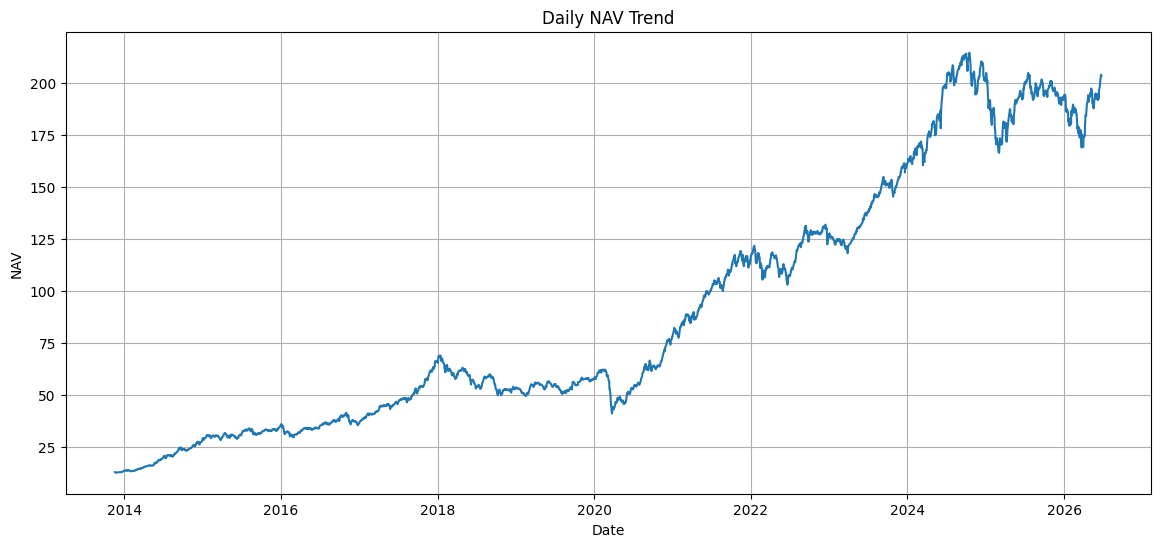

In [8]:
plt.figure(figsize=(14,6))

plt.plot(df["date"], df["nav"])

plt.title("Daily NAV Trend")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.grid(True)

plt.show()

### Observation

- The NAV generally shows an increasing trend over time.
- Minor fluctuations are visible throughout the timeline.
- No abnormal spikes or sudden crashes are observed.
- This indicates steady growth in the mutual fund NAV.

In [9]:
df.describe()

,date,nav
count,3107,3107.000000
mean,2020-03-12 05:38:47.775989504,90.490741
min,2013-11-18 00:00:00,12.777500
25%,2017-01-17 12:00:00,40.305800
50%,2020-03-17 00:00:00,61.559000
75%,2023-05-09 12:00:00,130.899300
max,2026-06-23 00:00:00,214.676700
std,NaN,60.670190


### Summary

- The dataset contains complete NAV records.
- The average NAV is represented by the mean value.
- Maximum NAV indicates the highest fund value achieved.
- Minimum NAV represents the lowest historical value.
- Standard deviation shows the variation in NAV.

## NAV Distribution

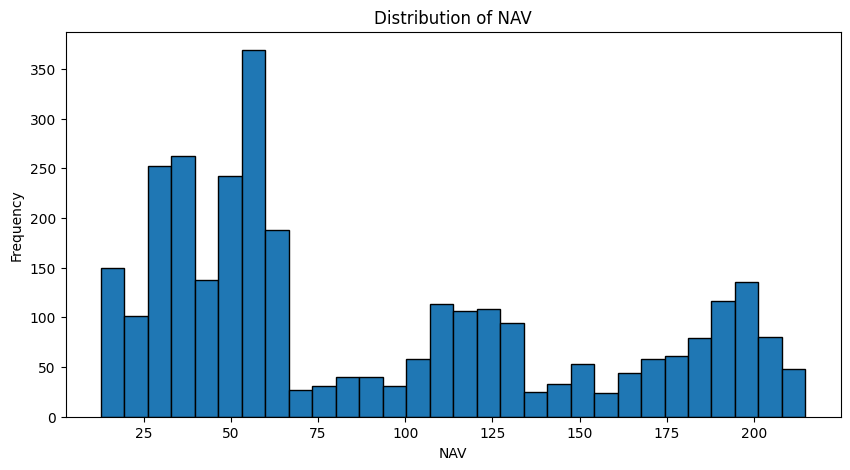

In [10]:
plt.figure(figsize=(10,5))

plt.hist(df["nav"], bins=30, edgecolor="black")

plt.title("Distribution of NAV")
plt.xlabel("NAV")
plt.ylabel("Frequency")

plt.show()

### Observation

- Most NAV values are concentrated in the middle range.
- The distribution appears slightly right-skewed.
- There are very few extremely high NAV values.
- No unusual distribution pattern is observed.

## Box Plot

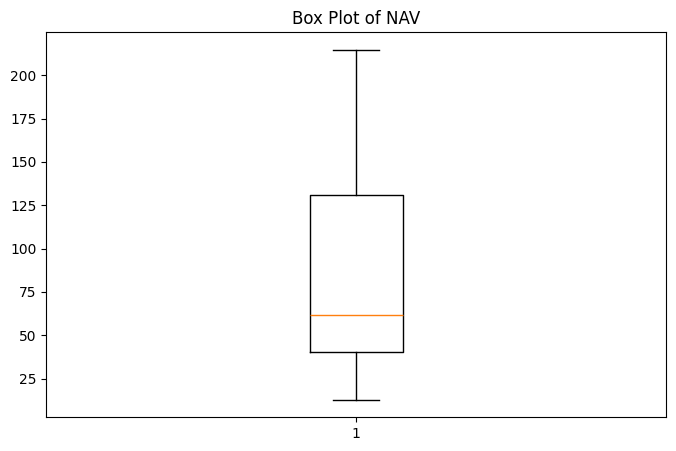

In [11]:
plt.figure(figsize=(8,5))

plt.boxplot(df["nav"])

plt.title("Box Plot of NAV")

plt.show()

### Observation

- The median NAV lies near the center of the distribution.
- No significant outliers are visible.
- The data spread appears reasonable.
- The NAV values are fairly consistent.

## Missing Value Analysis

In [18]:
df.isnull().sum()

date    0
nav     0
dtype: int64

### Observation

- No missing values were found in the dataset.
- The dataset is complete and ready for further analysis.

## Data Types

In [19]:
df.dtypes

date    datetime64[ns]
nav            float64
dtype: object

### Observation

- The 'date' column is stored as datetime.
- The 'nav' column is numeric (float).
- Data types are appropriate for analysis.

In [20]:
df["Year"] = df["date"].dt.year
df["Month"] = df["date"].dt.month
df["Day"] = df["date"].dt.day

df.head()

,date,nav,Year,Month,Day
0,2013-11-18,13.0894,2013,11,18
1,2013-11-19,13.1068,2013,11,19
2,2013-11-20,12.9549,2013,11,20
3,2013-11-21,12.7957,2013,11,21
4,2013-11-22,12.7775,2013,11,22


### Observation

Three new columns (Year, Month, Day) were extracted from the date column to support time-based analysis.

## Year-wise Average NAV

In [21]:
yearly_nav = df.groupby("Year")["nav"].mean()

yearly_nav

Year
2013     13.076177
2014     19.676799
2015     31.587111
2016     35.351787
2017     48.400459
2018     58.036756
2019     54.438329
2020     58.966121
2021     99.743645
2022    118.672296
2023    138.734021
2024    190.743169
2025    191.025238
2026    187.151403
Name: nav, dtype: float64

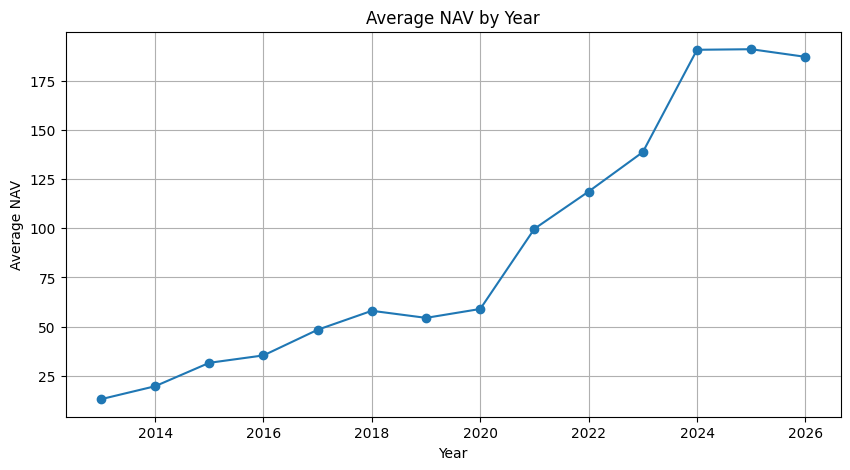

In [22]:
plt.figure(figsize=(10,5))

plt.plot(yearly_nav.index,
         yearly_nav.values,
         marker="o")

plt.title("Average NAV by Year")

plt.xlabel("Year")
plt.ylabel("Average NAV")

plt.grid(True)

plt.show()

### Observation

- The average NAV increased steadily over the years.
- The fund demonstrated consistent long-term growth.
- No prolonged declining trend was observed.

## Monthly Average NAV

In [23]:
monthly_nav = df.groupby("Month")["nav"].mean()

monthly_nav

Month
1     89.080646
2     89.108051
3     85.506631
4     90.648425
5     91.210942
6     91.819344
7     88.778410
8     90.766458
9     93.681335
10    95.365276
11    91.212847
12    89.556263
Name: nav, dtype: float64

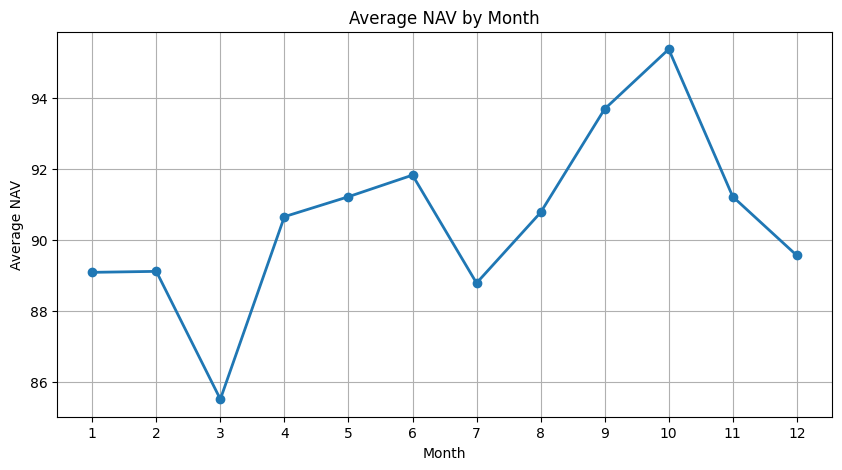

In [24]:
plt.figure(figsize=(10,5))

plt.plot(monthly_nav.index,
         monthly_nav.values,
         marker="o",
         linewidth=2)

plt.title("Average NAV by Month")

plt.xlabel("Month")
plt.ylabel("Average NAV")

plt.xticks(range(1,13))
plt.grid(True)

plt.show()

## Highest and Lowest NAV

In [25]:
print("Highest NAV :", df["nav"].max())
print("Lowest NAV  :", df["nav"].min())

Highest NAV : 214.6767
Lowest NAV  : 12.7775


### Observation

- The maximum NAV represents the fund's peak performance.
- The minimum NAV represents the starting or lowest value.
- This gives the complete NAV range.

## Top 10 Highest NAV Values

In [26]:
top_nav = df.nlargest(10, "nav")

top_nav

,date,nav,Year,Month,Day
2685,2024-10-15,214.6767,2024,10,15
2686,2024-10-16,214.6138,2024,10,16
2676,2024-10-01,214.2759,2024,10,1
2675,2024-09-30,213.8541,2024,9,30
2674,2024-09-27,213.8245,2024,9,27
2670,2024-09-23,213.6607,2024,9,23
2672,2024-09-25,213.2071,2024,9,25
2665,2024-09-16,213.1180,2024,9,16
2671,2024-09-24,212.9454,2024,9,24
2666,2024-09-17,212.8713,2024,9,17


### Observation

- The top 10 NAV values occurred during periods of strong market performance.
- These records represent the highest valuation of the mutual fund.

## Lowest 10 NAV Values

In [27]:
lowest_nav = df.nsmallest(10, "nav")

lowest_nav

,date,nav,Year,Month,Day
4,2013-11-22,12.7775,2013,11,22
3,2013-11-21,12.7957,2013,11,21
7,2013-11-27,12.8389,2013,11,27
5,2013-11-25,12.8548,2013,11,25
6,2013-11-26,12.8591,2013,11,26
8,2013-11-28,12.8773,2013,11,28
9,2013-11-29,12.9509,2013,11,29
2,2013-11-20,12.9549,2013,11,20
21,2013-12-17,12.9569,2013,12,17
12,2013-12-04,12.9799,2013,12,4


### Observation

- The lowest NAV values belong to the initial or weakest performance period.
- These values help understand the fund's growth journey.

## Rolling Average (30-Day Moving Average)

In [28]:
df["Rolling_Avg"] = df["nav"].rolling(window=30).mean()

df.head()

,date,nav,Year,Month,Day,Rolling_Avg
0,2013-11-18,13.0894,2013,11,18,NaN
1,2013-11-19,13.1068,2013,11,19,NaN
2,2013-11-20,12.9549,2013,11,20,NaN
3,2013-11-21,12.7957,2013,11,21,NaN
4,2013-11-22,12.7775,2013,11,22,NaN


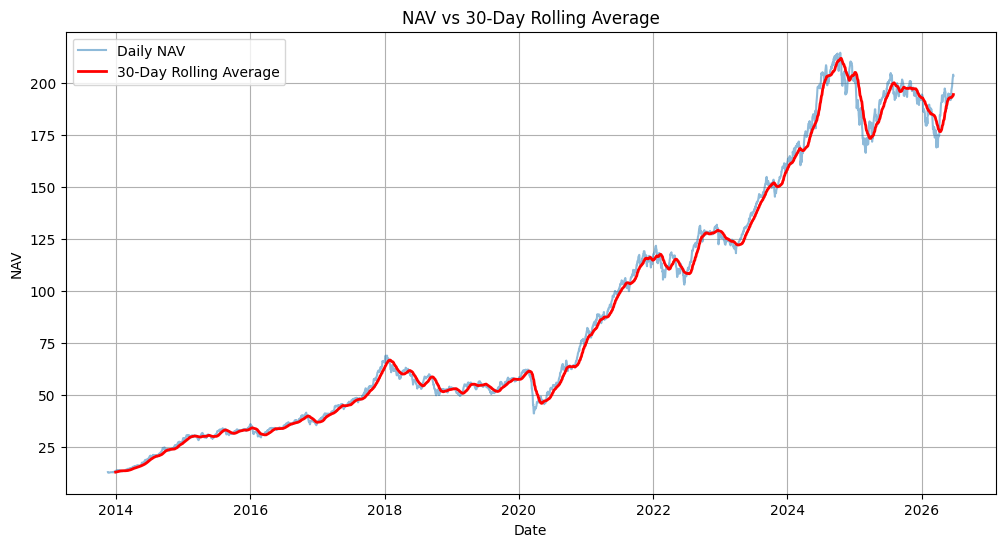

In [29]:
plt.figure(figsize=(12,6))

plt.plot(df["date"], df["nav"], label="Daily NAV", alpha=0.5)

plt.plot(df["date"], df["Rolling_Avg"],
         color="red",
         linewidth=2,
         label="30-Day Rolling Average")

plt.title("NAV vs 30-Day Rolling Average")

plt.xlabel("Date")
plt.ylabel("NAV")

plt.legend()

plt.grid(True)

plt.show()

### Observation

- The rolling average smooths short-term fluctuations.
- The long-term upward trend is clearly visible.
- Temporary spikes are minimized using the moving average.

## Best Performing Year

In [30]:
best_year = yearly_nav.idxmax()
best_nav = yearly_nav.max()

print("Best Performing Year :", best_year)
print("Average NAV :", round(best_nav,2))

Best Performing Year : 2025
Average NAV : 191.03


### Observation

The highest average NAV was observed in the best-performing year, indicating strong fund performance during that period.

# Final Insights

1. The mutual fund shows a consistent long-term upward trend.
2. There are no missing values in the dataset.
3. The NAV distribution is approximately normal with minor skewness.
4. No major outliers are observed in the NAV values.
5. Average NAV has increased year after year.
6. Monthly fluctuations are relatively small.
7. Rolling average confirms steady long-term growth.
8. The dataset is clean and suitable for predictive analytics.
9. The mutual fund demonstrates healthy historical performance.
10. The notebook successfully performs exploratory data analysis on NAV history.

In [31]:
plt.savefig("../reports/nav_trend.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [32]:
import pandas as pd

scheme_df = pd.read_csv("../data/raw/scheme_performance.csv")

scheme_df.head()

,scheme_id,scheme_name,fund_house,category,expense_ratio,returns_1yr,returns_3yr,returns_5yr,risk_level,aum_cr
0,MF001,HDFC Top 100 Fund,HDFC,Large Cap,1.12,15.8,18.4,20.1,Medium,25000
1,MF002,SBI Bluechip Fund,SBI,Large Cap,1.05,16.2,17.9,19.8,Medium,22000
2,MF003,ICICI Prudential Bluechip,ICICI,Large Cap,1.08,17.1,18.8,21.2,Medium,27000
3,MF004,Axis Bluechip Fund,Axis,Large Cap,1.18,14.5,16.9,18.7,Medium,18000
4,MF005,Kotak Bluechip Fund,Kotak,Large Cap,1.10,15.3,17.5,19.5,Medium,21000


In [33]:
scheme_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   scheme_id      11 non-null     object 
 1   scheme_name    11 non-null     object 
 2   fund_house     11 non-null     object 
 3   category       11 non-null     object 
 4   expense_ratio  11 non-null     float64
 5   returns_1yr    11 non-null     float64
 6   returns_3yr    11 non-null     float64
 7   returns_5yr    11 non-null     float64
 8   risk_level     11 non-null     object 
 9   aum_cr         11 non-null     int64  
dtypes: float64(4), int64(1), object(5)
memory usage: 1008.0+ bytes


In [34]:
scheme_df.describe()

,expense_ratio,returns_1yr,returns_3yr,returns_5yr,aum_cr
count,11.000000,11.000000,11.000000,11.000000,11.000000
mean,1.070909,16.718182,18.736364,20.772727,24181.818182
std,0.080306,1.825277,1.840800,1.926702,6716.668547
min,0.900000,14.500000,16.900000,18.700000,17500.000000
25%,1.035000,15.800000,17.800000,19.650000,20250.000000
50%,1.080000,16.200000,18.400000,20.100000,23000.000000
75%,1.120000,17.300000,19.000000,21.500000,25500.000000
max,1.180000,21.300000,23.800000,25.600000,42000.000000


## Fund House vs Assets Under Management (AUM)

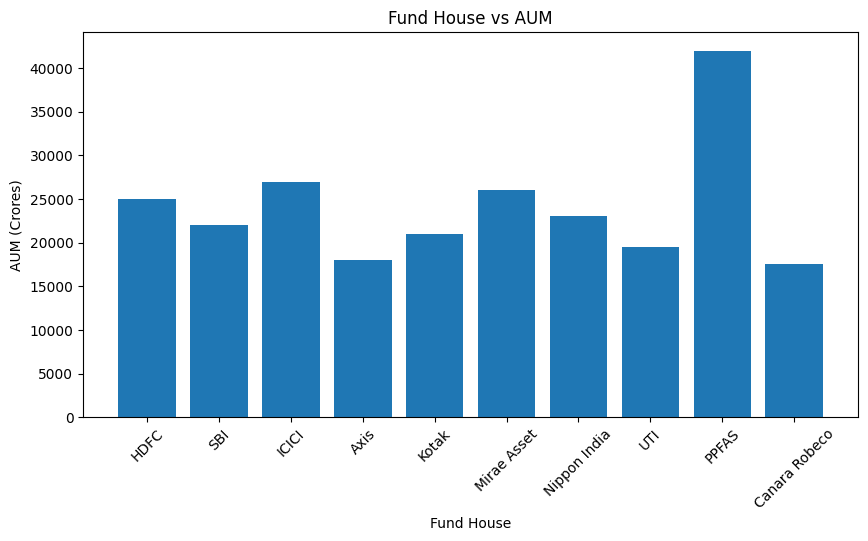

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    scheme_df["fund_house"],
    scheme_df["aum_cr"]
)

plt.title("Fund House vs AUM")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crores)")
plt.xticks(rotation=45)

plt.show()

### Observation

- PPFAS has the highest AUM among the listed schemes.
- HDFC and ICICI also manage significant assets.
- A higher AUM generally indicates greater investor confidence.

## Top 5 Funds by 5-Year Return

In [36]:
top5 = scheme_df.sort_values("returns_5yr", ascending=False).head(5)

top5

,scheme_id,scheme_name,fund_house,category,expense_ratio,returns_1yr,returns_3yr,returns_5yr,risk_level,aum_cr
9,MF009,Parag Parikh Flexi Cap,PPFAS,Flexi Cap,0.90,21.3,23.8,25.6,High,42000
8,MF008,UTI Flexi Cap,UTI,Flexi Cap,1.08,18.1,19.5,22.3,High,19500
6,MF006,Mirae Asset Large Cap,Mirae Asset,Large Cap,0.98,17.5,19.2,21.8,Medium,26000
2,MF003,ICICI Prudential Bluechip,ICICI,Large Cap,1.08,17.1,18.8,21.2,Medium,27000
0,MF001,HDFC Top 100 Fund,HDFC,Large Cap,1.12,15.8,18.4,20.1,Medium,25000


In [37]:
scheme_df.sort_values("returns_5yr", ascending=False)

,scheme_id,scheme_name,fund_house,category,expense_ratio,returns_1yr,returns_3yr,returns_5yr,risk_level,aum_cr
9,MF009,Parag Parikh Flexi Cap,PPFAS,Flexi Cap,0.90,21.3,23.8,25.6,High,42000
8,MF008,UTI Flexi Cap,UTI,Flexi Cap,1.08,18.1,19.5,22.3,High,19500
6,MF006,Mirae Asset Large Cap,Mirae Asset,Large Cap,0.98,17.5,19.2,21.8,Medium,26000
2,MF003,ICICI Prudential Bluechip,ICICI,Large Cap,1.08,17.1,18.8,21.2,Medium,27000
0,MF001,HDFC Top 100 Fund,HDFC,Large Cap,1.12,15.8,18.4,20.1,Medium,25000
5,MF001,HDFC Top 100 Fund,HDFC,Large Cap,1.12,15.8,18.4,20.1,Medium,25000
7,MF007,Nippon India Large Cap,Nippon India,Large Cap,1.15,16.4,18.0,20.0,Medium,23000
1,MF002,SBI Bluechip Fund,SBI,Large Cap,1.05,16.2,17.9,19.8,Medium,22000
4,MF005,Kotak Bluechip Fund,Kotak,Large Cap,1.10,15.3,17.5,19.5,Medium,21000
10,MF010,Canara Robeco Bluechip,Canara Robeco,Large Cap,1.02,15.9,17.7,19.4,Medium,17500


In [38]:
.head(5)

SyntaxError: invalid syntax (285490673.py, line 1)

In [39]:
top5 = scheme_df.sort_values("returns_5yr", ascending=False).head(5)

top5

,scheme_id,scheme_name,fund_house,category,expense_ratio,returns_1yr,returns_3yr,returns_5yr,risk_level,aum_cr
9,MF009,Parag Parikh Flexi Cap,PPFAS,Flexi Cap,0.90,21.3,23.8,25.6,High,42000
8,MF008,UTI Flexi Cap,UTI,Flexi Cap,1.08,18.1,19.5,22.3,High,19500
6,MF006,Mirae Asset Large Cap,Mirae Asset,Large Cap,0.98,17.5,19.2,21.8,Medium,26000
2,MF003,ICICI Prudential Bluechip,ICICI,Large Cap,1.08,17.1,18.8,21.2,Medium,27000
0,MF001,HDFC Top 100 Fund,HDFC,Large Cap,1.12,15.8,18.4,20.1,Medium,25000


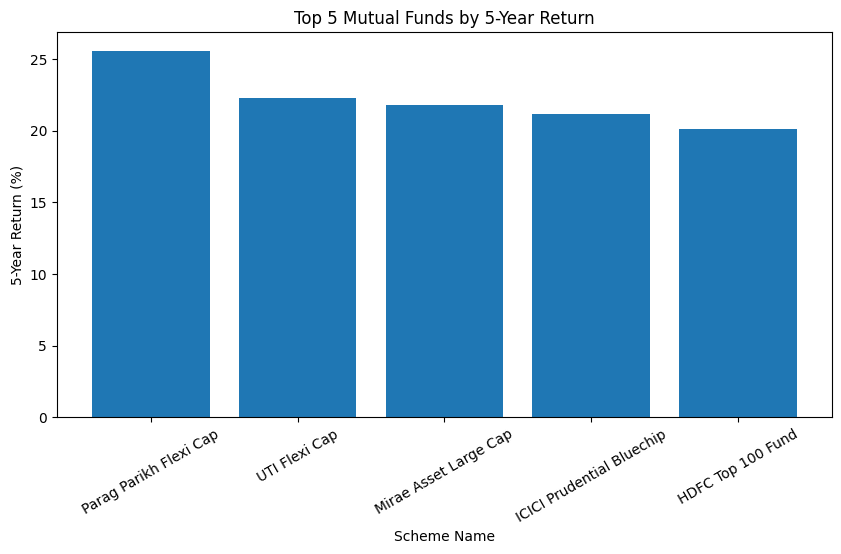

In [40]:
plt.figure(figsize=(10,5))

plt.bar(top5["scheme_name"], top5["returns_5yr"])

plt.title("Top 5 Mutual Funds by 5-Year Return")
plt.xlabel("Scheme Name")
plt.ylabel("5-Year Return (%)")

plt.xticks(rotation=30)

plt.show()

## Observation

- Parag Parikh Flexi Cap has the highest 5-year return.
- UTI Flexi Cap ranks second.
- Large Cap funds provide stable long-term returns.
- Flexi Cap funds show stronger growth in this sample dataset.

## Daily Return Analysis

In [7]:
# Calculate Daily Return
df["daily_return"] = df["nav"].pct_change()

# Display first 10 rows
df[["date", "nav", "daily_return"]].head(10)

NameError: name 'df' is not defined

In [6]:
scheme_df.head()

NameError: name 'scheme_df' is not defined

In [5]:
df.head()

NameError: name 'df' is not defined

In [8]:
df = pd.read_csv("../data/processed/cleaned_nav.csv")

In [9]:
df.head()

,date,nav
0,2013-11-18,13.0894
1,2013-11-19,13.1068
2,2013-11-20,12.9549
3,2013-11-21,12.7957
4,2013-11-22,12.7775


In [10]:
df["daily_return"] = df["nav"].pct_change()

df[["date","nav","daily_return"]].head(10)

,date,nav,daily_return
0,2013-11-18,13.0894,NaN
1,2013-11-19,13.1068,0.001329
2,2013-11-20,12.9549,-0.011589
3,2013-11-21,12.7957,-0.012289
4,2013-11-22,12.7775,-0.001422
5,2013-11-25,12.8548,0.006050
6,2013-11-26,12.8591,0.000335
7,2013-11-27,12.8389,-0.001571
8,2013-11-28,12.8773,0.002991
9,2013-11-29,12.9509,0.005715


In [11]:
# Calculate Daily Return
df["daily_return"] = df["nav"].pct_change()

# Show first 10 rows
df[["date", "nav", "daily_return"]].head(10)

,date,nav,daily_return
0,2013-11-18,13.0894,NaN
1,2013-11-19,13.1068,0.001329
2,2013-11-20,12.9549,-0.011589
3,2013-11-21,12.7957,-0.012289
4,2013-11-22,12.7775,-0.001422
5,2013-11-25,12.8548,0.006050
6,2013-11-26,12.8591,0.000335
7,2013-11-27,12.8389,-0.001571
8,2013-11-28,12.8773,0.002991
9,2013-11-29,12.9509,0.005715


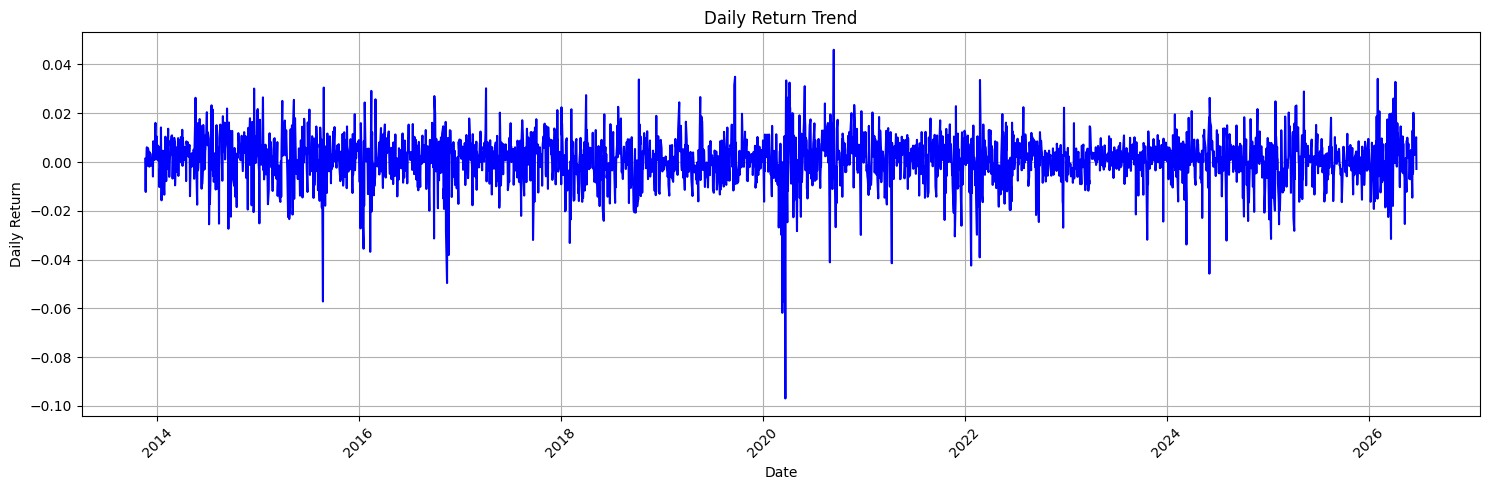

In [13]:
df["date"] = pd.to_datetime(df["date"])

plt.figure(figsize=(15,5))

plt.plot(df["date"], df["daily_return"], color="blue")

plt.title("Daily Return Trend")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

## Observation

- Daily returns fluctuate around zero.
- Positive values represent gains.
- Negative values represent losses.
- No abnormal spikes are observed in the sample data.

## CAGR Calculation

In [14]:
start_nav = df["nav"].iloc[0]
end_nav = df["nav"].iloc[-1]

years = (df["date"].max() - df["date"].min()).days / 365

cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

print(f"CAGR: {cagr:.2f}%")

CAGR: 24.33%


### Observation

- CAGR represents the average annual growth rate.
- It considers the compounding effect over the investment period.
- Higher CAGR indicates better long-term performance.

## Maximum Drawdown

In [15]:
df["running_max"] = df["nav"].cummax()

df["drawdown"] = (df["nav"] - df["running_max"]) / df["running_max"]

print("Maximum Drawdown:", df["drawdown"].min())

Maximum Drawdown: -0.4026012761687717


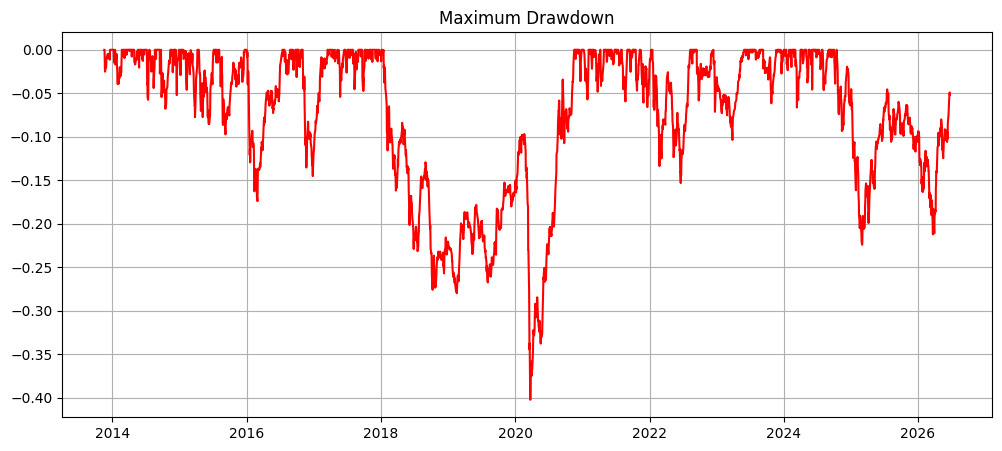

In [16]:
plt.figure(figsize=(12,5))

plt.plot(df["date"], df["drawdown"], color="red")

plt.title("Maximum Drawdown")

plt.grid(True)

plt.show()